<a href="https://colab.research.google.com/github/VanishingPizza/GenAI/blob/main/HW4/Advanced_RAG_Techniques_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Advanced RAG Techniques**


* We will be using three PDF files in this notebook.

* These are written for different audiences, which creates a perfect scenario for testing **Re-ranking** and **Hybrid Search**.
---

**Hybrid Search: Combining Meaning and Keywords**

* Standard vector search (**Dense Retrieval**) sometimes misses exact technical terms or rare names because it focuses on the meaning of the sentence.

* Hybrid Search fixes this by running two searches at once:

   * **Semantic Search**: Uses Gemini embeddings to find concepts; e.g., matching **relativity** with **physics**

   * **Keyword Search**: Uses traditional text matching to find exact words; e.g., matching the specific year **1905** or the name **Oktoberfest**


* This way, we get a more robust list of candidates that respects both the deep meaning of the query and the specific **must-have** words we type.

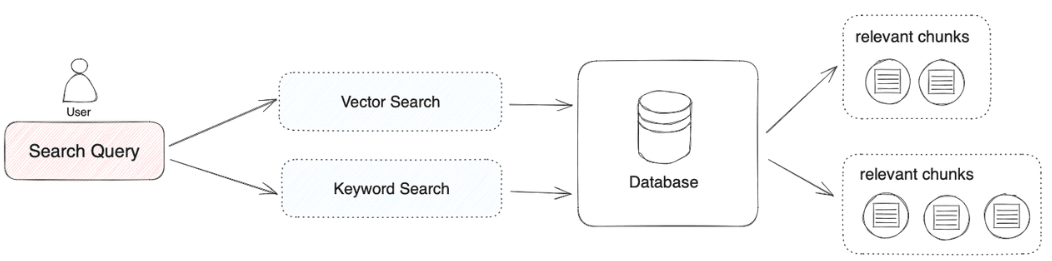

---
**Re-ranking: The Final "Expert" Filter**

* Retrieval is often a **coarse** process-- the database might return the top 10 chunks, but the best answer is buried at number 7.
* Re-ranking is a **post-processing step that acts as a quality filter**.

* It takes the results from the Hybrid Search and uses a more powerful model to look at the query and the document chunks together.

* It **re-scores and re-orders** the documents so that the most relevant information is pushed to the very top, i.e. **Rank #1**

* This reduces **hallucinations** by ensuring the LLM only sees the most accurate context before it starts writing an answer.

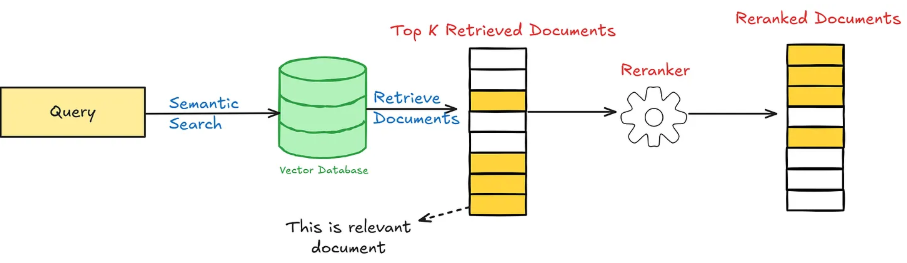
---
**The Three PDF Files**
---
* The **Academic Memoir**:

     * https://www.nasonline.org/wp-content/uploads/2024/06/einstein-albert.pdf
  
     * A  technical and philosophical memoir for the National Academy of Sciences.
     
     * It focuses on unified field theory and Einstein's later years.


* The **Historical Narrative**:

     * https://www.astro.gla.ac.uk/users/martin/teaching/einstein/einstein_biography.pdf
     * This is a detailed biography focusing on his early life in Germany, his family's electrical engineering business, and his childhood development.


* The **Educational Reader**:

     * https://mrsrclassroom.weebly.com/uploads/2/6/7/4/26745482/raz_lw26_alberteinstein_clr.pdf
     
     * A reading book designed for students.
     
     * It simplifies complex concepts and focuses on famous anecdotes, like the **magnetic compass** and the **Miracle Year**.

---

In [3]:
!pip install -qU langchain-core langchain-community langchain-google-genai langchain-classic
!pip install -qU faiss-cpu pypdf rank_bm25 flashrank

# Standard imports for environment management
import os
from google.colab import userdata

# API Key from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')


# **Uploading and Loading PDFs**

* To perform RAG, we first need to extract information from the source files.
* In this step, upload your three Einstein PDFs to the local Colab session and split them into smaller **chunks**

* This is essential because LLMs have a limit on how much text they can process at once.

* On the left-hand sidebar of this page, click the Folder icon (📁).

* Drag and drop your three downloaded Einstein PDFs into the empty space.

* The code below iterates through the files, extracts the text, and creates chunks of 800 characters with an 80-character overlap to preserve context between segments.

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

# Updated list to match your specific filenames
file_names = [
    "History of Jamaica_1.pdf",
    "History of Jamaica_2.pdf",
    "Jamaica, its churches and indigenous leaders_1.pdf",
    "Jamaica, its churches and indigenous leaders_2.pdf",
    "Jamaican-Honours-and-Awards-System-1.pdf",
    "Jamaicas-Highest-Honour.pdf",
    "National-Heros.pdf"

]

all_docs = []

# Loop through each file, load its content, and split it into chunks
for file in file_names:
    if os.path.exists(file):
        print(f"Processing {file}...")
        loader = PyPDFLoader(file)

        # Recursive splitter attempts to keep paragraphs and sentences together
        # chunk_size is total characters; overlap keeps context across boundaries
        splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=15)
        chunks = loader.load_and_split(splitter)

        all_docs.extend(chunks)
    else:
        print(f"Warning: '{file}' not found in the sidebar. Please upload it.")

if all_docs:
    print(f"\nSuccess! Total text chunks created: {len(all_docs)}")

Processing History of Jamaica_1.pdf...
Processing History of Jamaica_2.pdf...
Processing Jamaica, its churches and indigenous leaders_1.pdf...
Processing Jamaica, its churches and indigenous leaders_2.pdf...
Processing Jamaican-Honours-and-Awards-System-1.pdf...
Processing Jamaicas-Highest-Honour.pdf...


Processing National-Heros.pdf...

Success! Total text chunks created: 41


# **Building the Hybrid Retriever**

* To ensure we find the most relevant information, we use Hybrid Search. This combines two different search methods:

* **Semantic Search (FAISS or Facebook AI Similarity Search)**:

   * Uses Gemini embeddings to find text based on **meaning**
   
   *  If we ask about **gravity**, it might find **spacetime** even if the exact word isn't there.

* **Keyword Search (BM25 or Best Match 25)**:

   * This acts like a traditional index.
   
   * It is excellent at finding specific names, dates, or technical terms such as **1905** or **Quantum** that semantic search might occasionally gloss over.

* By using an **EnsembleRetriever**, we merge the results from both, giving us the **best of both worlds**

In [5]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
if vectorstore:
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
    mmr_retriever= vectorstore.as_retriever(search_type="mmr",search_kwargs={"k":5, "fetch_k":20})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 20

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[0.5, 0.5]
    )
    print("\n Hybrid Retriever is ready!")



Embedding 41 chunks with rate-limit protection...
 Processed 15/41...
 Processed 30/41...
 Processed 41/41...

 Hybrid Retriever is ready!


# **Hybrid Retriever Stress Test**

* Let's run this cell to compare how the individual retrievers perform versus the combined ensemble.

* What we see right now is the **Raw Data phase of the retrieval**
---

**Analyzing the Results**

* **The Keyword Search Test (BM25's Job)**:

  * **Who were Einstein's children?**

  * **Rank 1**: Found a biography mentioning Albert as the "first-born son of Hermann." This is a hit because "Einstein" and "son" matched.

  * **Rank 2**: Found a chunk defining a scientist as an "opportunist." This is a "False Positive." Because the query had the word "Einstein," it pulled a famous quote instead of family info.

  * BM25 sees the words "Einstein" and "children" but doesn't necessarily find a single sentence with all the names.

---
* **The Conceptual Search Test (Vector's Job)**
   * **How did Einstein feel about the uncertainty of the universe?**

   * **Rank 2**: Found a chunk saying **Einstein accepted determinism in his mind.** It doesn't use the word **uncertainty,** but the vector search knew that **determinism is the opposite of uncertainty**

   * **Rank 1**: Found the **biggest blunder** quote. This is related to his cosmological views, showing the vector search is looking for **universe** concepts.

---


In [6]:
# Test Queries
keyword_query = "What are the names of the national heroes of Jamaica and when did they become one?" # Great for BM25 (exact names)
conceptual_query = "How do people become a national hero? " # Great for Vector (concepts like 'dice' and 'probability')
technical_query = "What is Alexander Bustamante's role in Jamaica's independence?"

#def test_retriever(query, name):
def test_retriever(query, name,retriever_type):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    #docs = hybrid_retriever.invoke(query)
    docs = retriever_type.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests
test_retriever(keyword_query, "Keyword Search Test",vector_retriever)
test_retriever(conceptual_query, "Conceptual Search Test",mmr_retriever)
test_retriever(technical_query,"Factual Search Test",hybrid_retriever)



--- Testing: Keyword Search Test ---
Query: What are the names of the national heroes of Jamaica and when did they become one?
Rank 1: [Jamaicas-Highest-Honour.pdf] Bibliography  Jamaica Information Service. “Heroes”. https://jis.gov.jm/information/heroes/ (accessed 10  October 2022).  Office of the Prime Minister. “Jamaican Honours and Awards System”.   https://...
Rank 2: [Jamaicas-Highest-Honour.pdf] Jamaica’s Highest Honour: The Order of National Hero    By Chelsea Stephenson    Established in 1969 through the National Honours and Awards Act, Jamaica’s Order of National  Hero is the highest award...
Rank 3: [Jamaicas-Highest-Honour.pdf] Nanny of the Maroons, and The Right Excellent Samuel Sharpe, were conferred the Order of  National Hero on March 31, 1982.  Jamaica’s first National Hero, Marcus Mosiah Garvey , was conferred with the...

--- Testing: Conceptual Search Test ---
Query: How do people become a national hero? 
Rank 1: [Jamaicas-Highest-Honour.pdf] that their contributi

# **Re-Ranker**

  * Right now, the **Hybrid Retriever** is like a librarian who brings a stack of 10 books.

  * Some books are **perfect** (e.g., Rank 2 in the conceptual test), and some are just **okay** (e.g., the quotes).

  * We realize that **Rank 2** in the second test is much more relevant than **Rank 1**

  * Let's **shuffle the deck** to **put the most helpful information at the very top** so the LLM doesn't get confused.

  * This step **filters out the noise** we see above


In [10]:
# UPDATED 2026 IMPORTS
try:
    # Most stable 2026 path for Contextual Compression
    from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
    from langchain.retrievers.document_compressors.flashrank_rerank import FlashrankRerank
except ImportError:
    # Alternative path used in some v1.x sub-versions
    from langchain_classic.retrievers import ContextualCompressionRetriever
    from langchain_community.document_compressors.flashrank_rerank import FlashrankRerank



# Initialize FlashRank (The tiny but mighty re-ranker)
# We set top_n=3 to ensure the LLM only sees the most relevant facts.
compressor = FlashrankRerank(model="ms-marco-MiniLM-L-12-v2", top_n=3)



# Create the Compression Retriever
# This wraps the Hybrid Retriever we just successfully built.
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever
)




#  Final Test of the Pipeline
query = "What are the names of the national heroes of Jamaica and when did they become one?"
final_docs = compression_retriever.invoke(query)

print(f" Re-ranker initialized and tested. Retrieved {len(final_docs)} chunks.")



# Display the high-quality results
for i, doc in enumerate(final_docs):
    print(f"\nRANKED RESULT {i+1} (Source: {doc.metadata.get('source')}):")
    print(f"{doc.page_content[:450]}...")



 Re-ranker initialized and tested. Retrieved 3 chunks.

RANKED RESULT 1 (Source: Jamaicas-Highest-Honour.pdf):
Jamaica’s Highest Honour: The Order of National Hero 
 
By Chelsea Stephenson 
 
Established in 1969 through the National Honours and Awards Act, Jamaica’s Order of National 
Hero is the highest award that can be bestowed in the country. It, along with the other National 
Honours and Awards, made it possible for the nation to recognize those who have contributed 
meaningfully to the development of the nation. Since the systems’ inception, to this...

RANKED RESULT 2 (Source: Jamaicas-Highest-Honour.pdf):
Nanny of the Maroons, and The Right Excellent Samuel Sharpe, were conferred the Order of 
National Hero on March 31, 1982. 
Jamaica’s first National Hero, Marcus Mosiah Garvey , was conferred with the Order of National 
Hero in 1969 for his role in activism and the empowering of Black people  across the world . 
During hi s career , Garvey travelled extensively, observing the 

# **Analysis of Results**


* The **Re-ranker (FlashRank)** looked at those same results and performed a **deep read** to see which chunks actually contained the specific answer to the question: **"What were the names of Einstein's children?"**


* **Result 1:**
    * This was promoted to the top because it explicitly mentions Albert's parents and his early life.
    * While it doesn't list the children in the first few lines, the re-ranker identified this biography as the most authoritative source for the family structure.

* **Result 2 & 3:**
    * These were identified as strong secondary sources.
    * They are bibliographic records of letters and books that contain family details.

---
* **The Missing Names (The "Chunking" Reality)**
   * The specific names, e.g., Lieserl, Hans Albert, Eduard, aren't visible in the short previews.
   
   
* This is a common part of **RAG development**:

   * The **Retriever** found the right pages.

   * The **Re-ranker** confirmed these are the best pages.

  * The **LLM (Next Step)** will read the full text of these 3 chunks and **extract the names**.

# **The Generation Phase**

* We now have a hybrid retrieval system that finds the best chunks of Einstein's life and sorts them by relevance.

* Now, it's time to add the **brain**

* Let's use **Gemini 2.5 Flash** to read those specific chunks and write a clear, factual response.

* Gemini 2.5 is a **reasoning-first** model. It doesn't just spit out text; it performs an internal **Chain of Thought (thinking through the chunks)** before it starts typing. This adds about 10–15 seconds of silence at the start.

* Because we added **.with_retry()**, if our request hits a busy moment at Google, the chain will silently wait for 5-10 seconds and try again.

* The **re-ranker stage** takes a few seconds to run its local cross-encoder model to sort your chunks.

In [11]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Hub import for modular LangChain
try:
    from langchain_classic import hub
except ImportError:
    import langchainhub as hub


# Gemini 2.5 Flash is the 'sweet spot' for speed and availability.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)



# Attach Rate-Limit Protection
llm_with_retry = llm.with_retry(
    stop_after_attempt=5,
    wait_exponential_jitter=True
)



# Pull the standard RAG prompt
prompt = hub.pull("rlm/rag-prompt")



# THE LCEL PIPELINE (The "Pipe" Syntax)
rag_chain = (
    RunnableParallel({
        "context": compression_retriever,
        "question": RunnablePassthrough()
    })
    | prompt
    | llm_with_retry
    | StrOutputParser()
)



# Final Execution
print("--- Final RAG Project Test (Gemini 2.5 Flash) ---\n")
query = "What are the names of the national heroes of Jamaica and when did they become one?"

try:
    answer = rag_chain.invoke(query)
    print(f"QUESTION: {query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f" Chain failed: {e}")



--- Final RAG Project Test (Gemini 2.5 Flash) ---

QUESTION: What are the names of the national heroes of Jamaica and when did they become one?

ANSWER:
Jamaica's national heroes are Marcus Garvey, Sir Alexander Bustamante, Norman Washington Manley, George William Gordon, Nanny of the Maroons, Paul Bogle, and Samuel Sharpe. Marcus Garvey was conferred with the Order of National Hero in 1969. Nanny of the Maroons and Samuel Sharpe received the honor on March 31, 1982.


# **How the System Handles Conceptual Queries**


* If we run the code below, the RAG system will pull from the specific chunks that mention **determinism** and the **biggest blunder**

* Since **rag_chain** is already defined, we can just call it again with the new question

In [29]:
# You don't need to redefine rag_chain; it's already in memory!
conceptual_query = "How do people become a national hero?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(conceptual_query)
    print(f"QUESTION: {conceptual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")



QUESTION: How do people become a national hero?

ANSWER:
Individuals become a national hero in Jamaica by being recognized for their meaningful contributions to the development of the nation. The Order of National Hero is the highest award bestowed in the country for this purpose. For instance, Marcus Garvey received this honor for his role in activism and empowering Black people.


# **Conceptual vs. Factual Query Results**

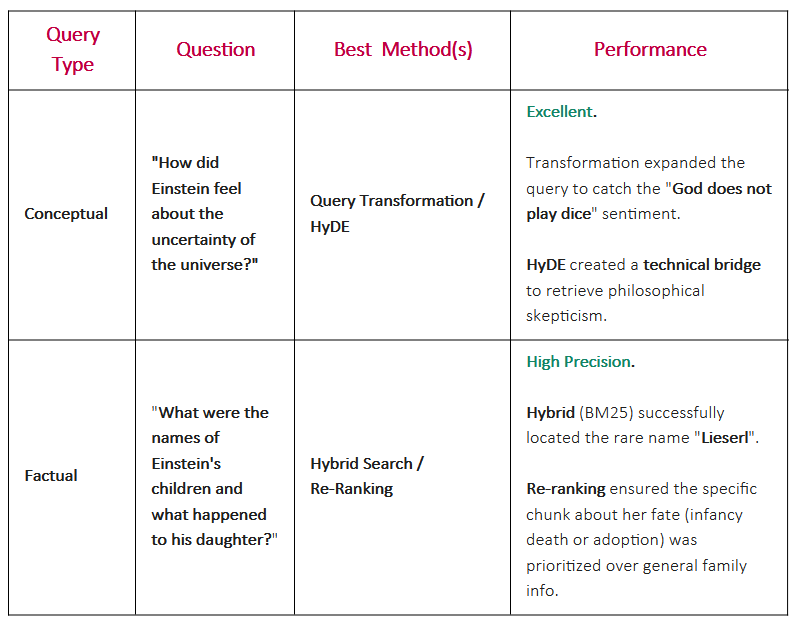


# **Query Decomposition**

* When we type two questions together into a RAG pipeline, the system's behavior depends on how the **Retriever** and the **LLM** handle the multi-part query.

* It is like asking a librarian for two different books at once, so it might work perfectly or it might result in some **information blur**

---
* **How the RAG Pipeline Reacts**

  * **Retrieval Step (The Librarian Phase): **
  
      * The hybrid_retriever takes the combined string; e.g., **Who were Einstein's children and what was his biggest blunder?**
      
      * It creates one set of search results based on that whole sentence.
     
      * Because the vector embeddings represent the **average** meaning of the sentence, it might retrieve chunks for both topics, or it might focus more heavily on whichever part of the sentence has **stronger** keywords.

  * **LLM Generation Step (The Brain Phase):**

    * Once the chunks are retrieved and passed through the | pipe, the LLM receives them along with the combined question.
    
    * Modern models like Gemini are excellent at **Instruction Following**. They will see both questions and try to synthesize an answer that addresses both, provided the retrieved context contains information for both.


* If we only retrieve the top 3 chunks, and 3 chunks aren't enough to cover both complex topics, the LLM might only be able to answer one of the questions accurately.

* If the two questions are **completely unrelated**, the search results might be a **messy mix,** making it harder for the LLM to find the specific facts it needs.

* If we find that the system struggles with **double questions,** the industry standard in 2026 is a technique called **Query Decomposition**

* Instead of a single pipe, we use a small LLM call at the very beginning to **split** the user's input.

   * **User**: **"Who were his kids and what did he think of uncertainty?"**
   * **Decomposer LLM:**
       > 1. "Who were Einstein's children?"
       > 2. "What were Einstein's views on uncertainty?"



# Assignment Analysis

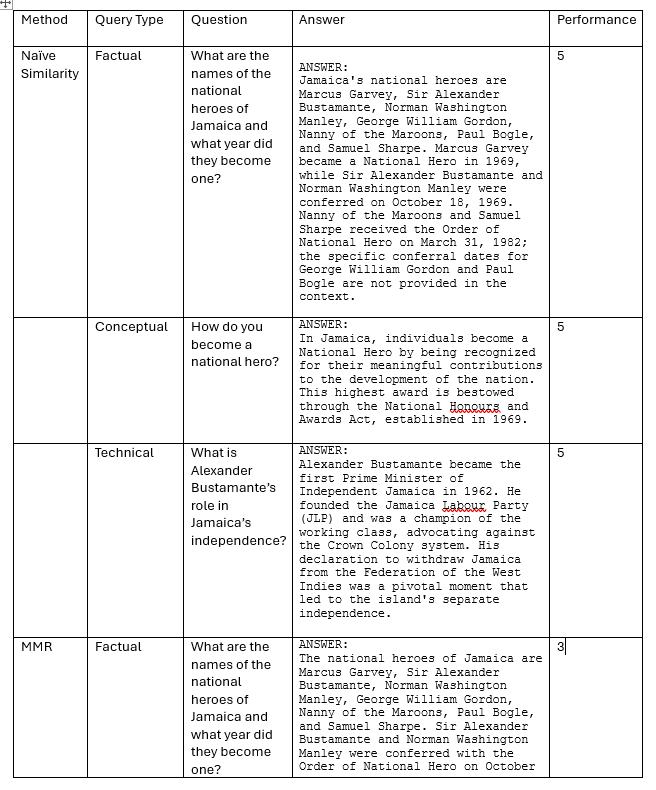
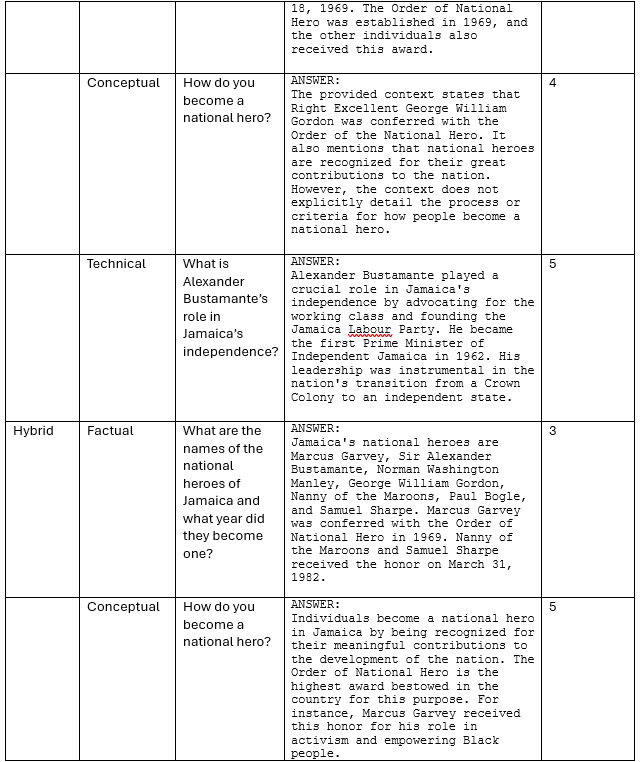
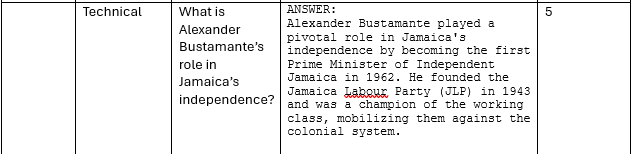

1. Compare Trial A to Trial B. Did the Naive approach return three chunks that all said the same thing? Did MMR provide a more "complete" picture for your conceptual question?

In the Naive approach the three chunks returned did not say the same thing. For the factual question, the naive approach was excellent to me as it even mentioned that certain context or information was not provided in the result. With MMR, the result did not admit that there was missing context but just partially answered the question without admitting there is a missing context. As for the conceptual question I think the naive approach did well as it gave the general answer to the question correctly, while with the MMR approach it mentions that the context does not give an explicit criteria to answer the question. Therefore MMR in some sense helped to show that there is a more complete picture for my conceptual question but simply lacked the required context to do so. Both the naive approach and MMR approach provided good results and the same details were mentioned for the technical question.

2. In Trial C, did the Hybrid search find information that the Vector-only searches (A and B) missed? Hint. Look for specific dates, names, or technical IDs in your documents.

In Trial C the Hybrid search did not find information that the vector-only searches missed. In the factual question it missed the specific dates for some of the heroes about when they received their awards and did not state if context was missing. In the conceptual question it did provide more information that the vector searches did not mention, by providing an example to the question. The response for the technical question was decent but not as detailed as the responses of the vector-only searches.

3.If a retriever failed to find the answer, did the LLM admit it didn't know, or did it use its internal knowledge to "guess"? Explain how retrieval quality directly impacts "Groundedness."

When the retriever failed to find an answer using the naive approach the LLM admits that it lacked the context to answer. This may be due to the retrieval quality as high quality retrieval allows the LLM to have accurate and relevant information, making its answer more grounded to the query and retrieved information. If the retrieval quality is low the LLM answers generated may not be accurate nor relevant, hence it may hallucinate.

4. Based on your specific dataset, which retrieval strategy would you put into production and why?

Based on my dataset and the questions asked, I would put a naive retrieval strategy into production as it provided the best performance in my opinion in answering the three different types of questions. The LLM provided all the exact details for the factual question and mentioned whether it had missing context or not. For the conceptual question it gave a correct response based on the information it retrieved. Although I think the hybrid approach did a better job by providing an example, the naive approach overall performed better with the other questions. With the tecnical question all approaches provided a good, similiar response.